## Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchinfo import summary
import numpy as np

 ## Используем доступное устройство: GPU(CUDA), если видеокарта - NVIDIA, иначе - CPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Вычисление статистик(mean, std) для последующей Z-нормализации 

In [3]:
temp_train = torchvision.datasets.MNIST(root='mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_mean = temp_train.data.float().mean() / 255
mnist_std = temp_train.data.float().std() / 255

## Создаём трансформер, чтобы сразу переводить данные в тензоры + нормализовывать их

In [4]:
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean.item(), mnist_std.item())
])

## Загружаем данные, делим трейн на трейн и валидацию, используем Dataloader, чтобы подавать данные батчами

In [5]:
TRAIN_SIZE = 50000
VALIDATION_SIZE = 10000
BATCH_SIZE = 128

train_dataset = torchvision.datasets.MNIST(root='mnist',download=True,train=True,transform=transformer)
test_dataset = torchvision.datasets.MNIST(root='mnist',download=True,train=False,transform=transformer)

train_subset, val_subset = random_split(train_dataset, [TRAIN_SIZE, VALIDATION_SIZE])

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
print(f"Кол-во батчей на трейне: {len(train_loader)}")
print(f"Кол-во батчей на валидации: {len(valid_loader)}")
print(f"Кол-во батчей на тесте: {len(test_loader)}")

Кол-во батчей на трейне: 391
Кол-во батчей на валидации: 79
Кол-во батчей на тесте: 79


## Функция обучения: 
Активирует процесс обучения, считая на каждой эпохе ошибку на валидации,на трейне, также AccuracyScore на трейне и валидации и отстраивает график, обновляя его для каждой новой эпохи

In [7]:
def train(model, optimizer, epochs=10):
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()     
            outputs = model(images)    
            loss = criterion(outputs, labels) 
            loss.backward()            
            optimizer.step()           
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad(): 
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        train_loss_avg = train_loss / len(train_loader)
        train_acc_avg = train_correct / train_total
        val_loss_avg = val_loss / len(valid_loader)
        val_acc_avg = val_correct / val_total
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc_avg)
        history['val_acc'].append(val_acc_avg)
        
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Epoch {epoch+1} Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_acc'], label='Train Acc')
        plt.plot(history['val_acc'], label='Val Acc')
        plt.title(f'Epoch {epoch+1} Accuracy')
        plt.legend()
        
        plt.show()
        print(f"Epoch {epoch+1}: Train Loss {train_loss_avg:.4f}, Val Acc {val_acc_avg:.4f}, Val Loss {val_loss_avg:.4f}, Train Acc {train_acc_avg:.4f}")

## Используем Базовую модель(как в семинаре)

In [8]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28,128),
    nn.ReLU(),
    nn.Linear(128,10)
)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
summary(model, input_size=(BATCH_SIZE,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [128, 10]                 --
├─Flatten: 1-1                           [128, 784]                --
├─Linear: 1-2                            [128, 128]                100,480
├─ReLU: 1-3                              [128, 128]                --
├─Linear: 1-4                            [128, 10]                 1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.03
Input size (MB): 0.40
Forward/backward pass size (MB): 0.14
Params size (MB): 0.41
Estimated Total Size (MB): 0.95

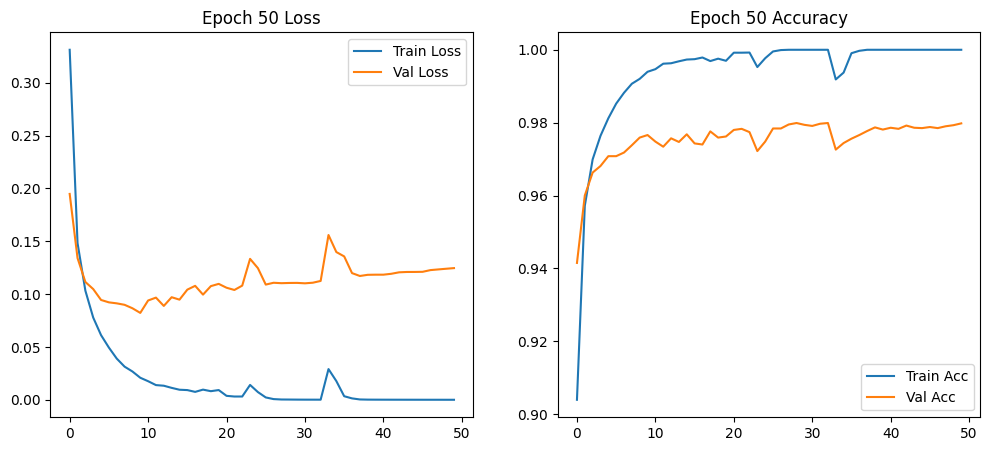

Epoch 50: Train Loss 0.0000, Val Acc 0.9798, Val Loss 0.1246, Train Acc 1.0000


In [9]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
train(model,optimizer, epochs = 50)
min_val_loss_base = min(history['val_loss'])

### Вывод о использовании базовой модели:
Анализ графиков показывает картину сильного переобучения. 
К 50-й эпохе точность на тренировке Train Acc достигла абсолютных 1.0000, а ошибка Train Loss упала почти до нуля. Сеть идеально подстроилась под обучающую выборку. При этом кривая валидационной ошибки (Val Loss) остановилась на высоком уровне 0.1246. Огромный разрыв между тренировочной и валидационной кривой Loss доказывает, что простая полносвязная архитектура не способна к дальнейшему обобщению новых данных.

### Используем более усовершенствованную модель
Добавим больше нейронов в скрытых слоях, используем BatchNorm, Dropout для улучшения скорости сходимости и избежания переобучения, также возьмём ELU, так как она позволяет избежать проблемы умирающих нейронов и обеспечивает среднее значение активаций, близкое к нулю.

In [10]:
model_improved = nn.Sequential(
     nn.Flatten(),
    
    nn.Linear(784, 512),
    nn.BatchNorm1d(512),
    nn.ELU(alpha=1), 
    nn.Dropout(0.2),   
    
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ELU(alpha=1),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ELU(alpha=1),
    nn.Dropout(0.3),
    
    nn.Linear(128, 10)
)
model_improved.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_improved.parameters(), lr = 0.001)
summary(model_improved, input_size=(BATCH_SIZE,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [128, 10]                 --
├─Flatten: 1-1                           [128, 784]                --
├─Linear: 1-2                            [128, 512]                401,920
├─BatchNorm1d: 1-3                       [128, 512]                1,024
├─ELU: 1-4                               [128, 512]                --
├─Dropout: 1-5                           [128, 512]                --
├─Linear: 1-6                            [128, 256]                131,328
├─BatchNorm1d: 1-7                       [128, 256]                512
├─ELU: 1-8                               [128, 256]                --
├─Dropout: 1-9                           [128, 256]                --
├─Linear: 1-10                           [128, 128]                32,896
├─BatchNorm1d: 1-11                      [128, 128]                256
├─ELU: 1-12                              [128, 128]               

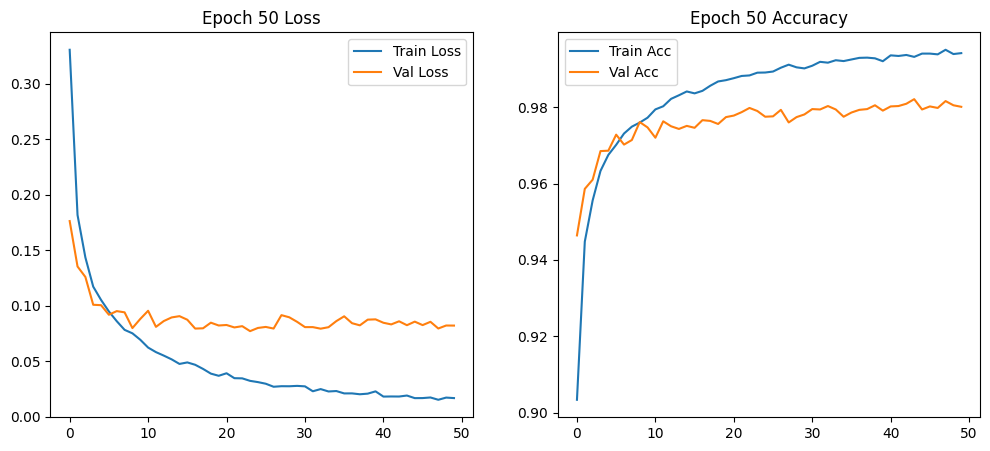

Epoch 50: Train Loss 0.0170, Val Acc 0.9801, Val Loss 0.0823, Train Acc 0.9942


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
train(model_improved,optimizer,epochs=50)
min_val_loss_improved = min(history['val_loss'])

### Вывод о использовании улучшенной модели:
Внедрение слоев регуляризации качественно изменило графики обучения:

* **Влияние Dropout (0.3):** Он успешно предотвратил идеальное запоминание. Теперь кривая Train Loss не падает в абсолютный ноль (остановившись на 0.0170), а Train Acc не достигает 100% (0.9942). Это признак регуляризации, модель вынуждена искать общие закономерности.
* **Влияние Batch Normalization:** Графики стали более стабильными, а разрыв между Train Loss и Val Loss существенно сократился. 
* **Результат:** Благодаря этим изменениям, ошибка на валидации (Val Loss) снизилась в 1.5 раза с 0.1246 (у базы) до 0.0823, что подтверждает качественный рост обобщающей способности модели.

## Используем последнюю модель
Добавим свёрточные слои и пуллинг, чтобы улавливать важные пространственные признаки(линии, контуры))

In [12]:
model_champion = nn.Sequential(

    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), 
    
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Flatten(), 
    
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

model_champion.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_champion = optim.Adam(model_champion.parameters(), lr=0.001)

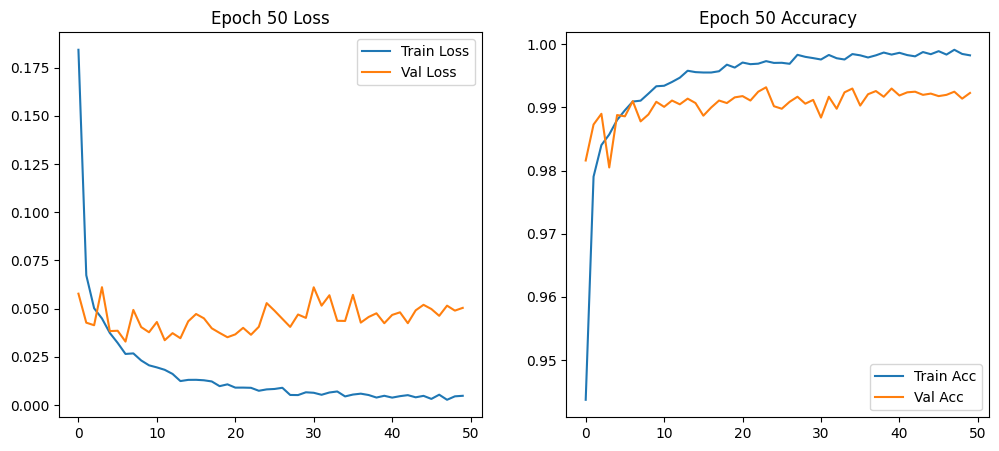

Epoch 50: Train Loss 0.0048, Val Acc 0.9923, Val Loss 0.0504, Train Acc 0.9983


In [13]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
train(model_champion, optimizer_champion, epochs=50)
min_val_loss_champion = min(history['val_loss'])

### Вывод о использовании чемпионской модели:
Сверточная архитектура (CNN) демонстрирует графики с наилучшей динамикой:

* **ValLoss (0.0504):** Ошибка на валидации упала до рекордного минимума, что почти в 2.5 раза ниже, чем у базовой полносвязной модели.
* **Обобщение:** Кривые Train и Val идут максимально близко друг к другу. Модель успешно извлекает пространственные признаки (контуры, линии, изгибы), что позволяет уверенно получить Accuracy > 99 %. Это доказывает, что для анализа изображений слои (Conv2d) являются весьма эффективными.

In [15]:
import pandas as pd

def get_metrics(model, loader, name, min_val_loss):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return [name,f"{min_val_loss:.4f}", f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}"]

data = []
data.append(get_metrics(model, test_loader, "1. Базовая модель",min_val_loss_base))
data.append(get_metrics(model_improved, test_loader, "2. Улучшенная",min_val_loss_improved))
data.append(get_metrics(model_champion, test_loader, "3. Чемпионская",min_val_loss_champion))

report = pd.DataFrame(data, columns=['Модель','MinValLoss', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
display(report)

,Модель,MinValLoss,Accuracy,Precision,Recall,F1-score
0,1. Базовая модель,0.0822,0.9791,0.9791,0.9789,0.9790
1,2. Улучшенная,0.0773,0.9825,0.9824,0.9824,0.9824
2,3. Чемпионская,0.0329,0.9927,0.9927,0.9926,0.9926


# Итоговое заключение по проделанной работе

В ходе экспериментов были рассмотрены три архитектуры нейронных сетей для классификации цифр MNIST. Добавление детального логирования метрик на графиках позволило выявить критические различия в их поведении:

### Сравнение базовой и улучшенной модели
* **Борьба с переобучением:** На графике базовой модели зафиксировано стопроцентное переобучение: Train Loss = 0.0000, Train Acc = 1.0000, что привело к огромному зазору с Val Loss (0.1246). В улучшенной модели `Dropout` намеренно усложнил обучение поэтому Train Loss вырос до 0.0170,что позволило снизить ошибку валидации до 0.0823.
* **Стабильность градиентов:** Использование `BatchNorm` и функции `ELU` сделало сходимость более плавной, позволив весам сети распределяться равномернее.

### Почему чемпионская модель лучше всех
Наилучший скор на тесте показала сверточная нейронная сеть. Это объясняется её архитектурной природой:
* **Пространственные способности:** В отличие от полносвязных слоев, воспринимающих картинку как одномерный вектор, свертки используются для поиска двумерных паттернов (углов, линий).
* **Итоговая эффективность:** Это позволило минимизировать потерю информации и снизить ошибку валидации до 0.0504 при Accuracy свыше 99.2%.

### Общий вывод:
* Для решения задачи классификации MNIST оптимальной является сверточная архитектура. Однако на примере полносвязных сетей было наглядно доказано, что использование механизмов регуляризации (Dropout) и нормализации (BatchNorm) позволяет существенно повысить обобщающую способность модели, даже если визуально графики обучения кажутся идентичными. Стоит отметить, что наглядно можно увидеть, что даже простая нейронная сеть получила высокий скор на тесте, но это обусловлено в первую очередь простотой датасета MNIST, в котором нет явных шумов в данных и сложных зависимостей.